In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0+cu130'

In [2]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(
  n_samples,
  noise=0.03,
  random_state=42
)

In [3]:
print(f"5 First X label : {X[:5]}")
print(f"5 First y label : {y[:5]}")

5 First X label : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
5 First y label : [1 1 1 1 0]


In [4]:
import pandas as pd

circles = pd.DataFrame({
  "X1": X[:, 0],
  "X2": X[:, 1],
  "label": y
})

circles[:10]

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
# label di ambil dari yang kita buat y tadi
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

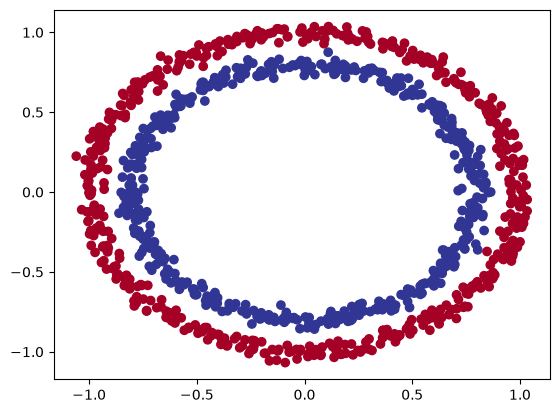

In [6]:
plt.scatter(
  x=X[:, 0],
  y=X[:, 1],
  c=y,
  cmap=plt.cm.RdYlBu
)

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [9]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [11]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

device


'cuda'

In [12]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=2, out_features=5)
    self.layer2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer2(self.layer1(x))

model_0 = CircleModelV0()

model_0

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
model_0 = nn.Sequential(
  nn.Linear(in_features=2, out_features=5),
  nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.3002],
        [-0.3443],
        [-0.2705],
        [-0.3083],
        [-0.4063],
        [-0.4322],
        [-0.4484],
        [-0.4693],
        [-0.2648],
        [-0.3487]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [15]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [16]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

# tambahan  : Kegunaan sum yaitu menghitung jumlah True nya hasil dari Perbandingan 2 Variabel
#             Dimana ketika sum hasilnya adalah tensor "tensor(2)" maka tambahkan item()
#             agar berubah menjadi "2" saja yang di return

In [17]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.3002],
        [-0.3443],
        [-0.2705],
        [-0.3083],
        [-0.4063]], device='cuda:0', grad_fn=<SliceBackward0>)

In [18]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4255],
        [0.4148],
        [0.4328],
        [0.4235],
        [0.3998]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [19]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()) )

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [20]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [21]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train.to(device))

  acc = accuracy_fn(y_true=y_train.to(device), y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()

  with torch.inference_mode():
    test_logits = model_0(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test.to(device))
    test_acc = accuracy_fn(y_true=y_test.to(device), y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch : {epoch} | Loss : {loss} | Accuracy : {acc}% | Test Loss : {test_loss} | Test Accuracy : {test_acc}%")

Epoch : 0 | Loss : 0.7094383835792542 | Accuracy : 50.0% | Test Loss : 0.7066519856452942 | Test Accuracy : 50.0%
Epoch : 10 | Loss : 0.6992226243019104 | Accuracy : 50.0% | Test Loss : 0.6981809139251709 | Test Accuracy : 50.0%
Epoch : 20 | Loss : 0.6955485343933105 | Accuracy : 50.0% | Test Loss : 0.6953811645507812 | Test Accuracy : 50.0%
Epoch : 30 | Loss : 0.6941599249839783 | Accuracy : 42.5% | Test Loss : 0.6944877505302429 | Test Accuracy : 42.0%
Epoch : 40 | Loss : 0.6936082243919373 | Accuracy : 47.625% | Test Loss : 0.6942419409751892 | Test Accuracy : 44.0%
Epoch : 50 | Loss : 0.6933730244636536 | Accuracy : 49.125% | Test Loss : 0.694209098815918 | Test Accuracy : 47.5%
Epoch : 60 | Loss : 0.6932613849639893 | Accuracy : 48.75% | Test Loss : 0.6942389011383057 | Test Accuracy : 50.0%
Epoch : 70 | Loss : 0.6932000517845154 | Accuracy : 49.0% | Test Loss : 0.6942811608314514 | Test Accuracy : 49.5%
Epoch : 80 | Loss : 0.6931605339050293 | Accuracy : 49.5% | Test Loss : 0.694

In [22]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


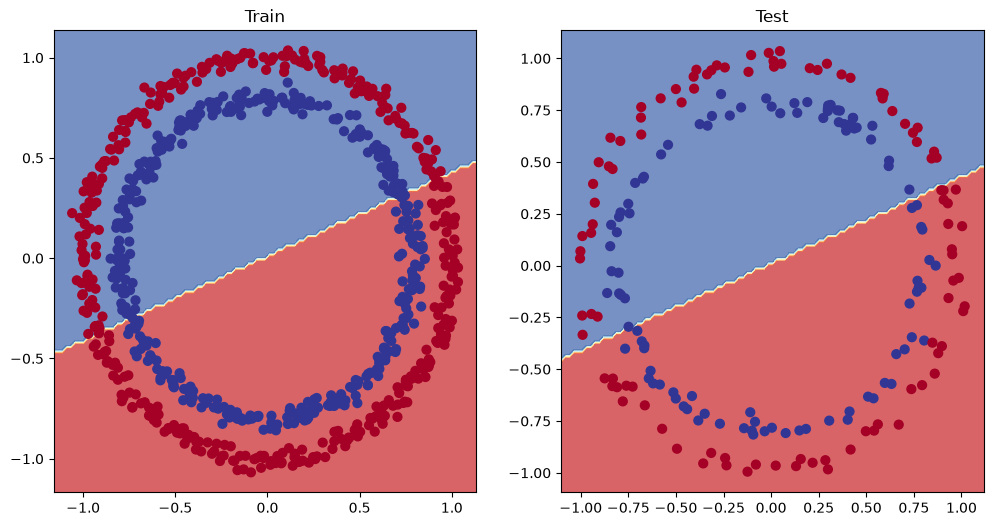

In [23]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

Sepertinya Model Undeflitting alias garis lurus , hemm kita bisa mengimprovenya disini
Kita coba pakai HyperParameter dimana menambah hidden layer + epoch ditambahkan

In [24]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [25]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [26]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train.to(device))
  acc = accuracy_fn(y_true=y_train.to(device), y_pred=y_pred)
  
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test.to(device))
    test_acc = accuracy_fn(y_true=test_pred, y_pred=y_test.to(device))

  if(epoch % 100 == 0):
    print(f"Epoch : {epoch} | Loss : {loss} : Acc : {acc}% | Test Loss : {test_loss} | Test Acc : {test_acc}%")



Epoch : 0 | Loss : 0.6939550638198853 : Acc : 50.875% | Test Loss : 0.6926145553588867 | Test Acc : 51.0%
Epoch : 100 | Loss : 0.6930478811264038 : Acc : 50.375% | Test Loss : 0.6937904357910156 | Test Acc : 48.0%
Epoch : 200 | Loss : 0.6929860711097717 : Acc : 51.125% | Test Loss : 0.6943727135658264 | Test Acc : 46.0%
Epoch : 300 | Loss : 0.6929804682731628 : Acc : 51.625% | Test Loss : 0.6945767998695374 | Test Acc : 45.0%
Epoch : 400 | Loss : 0.6929798722267151 : Acc : 51.125% | Test Loss : 0.6946452260017395 | Test Acc : 46.0%
Epoch : 500 | Loss : 0.6929798722267151 : Acc : 51.0% | Test Loss : 0.6946679353713989 | Test Acc : 46.0%
Epoch : 600 | Loss : 0.6929798722267151 : Acc : 51.0% | Test Loss : 0.6946756839752197 | Test Acc : 46.0%
Epoch : 700 | Loss : 0.6929798722267151 : Acc : 51.0% | Test Loss : 0.6946781873703003 | Test Acc : 46.0%
Epoch : 800 | Loss : 0.6929798722267151 : Acc : 51.0% | Test Loss : 0.6946790814399719 | Test Acc : 46.0%
Epoch : 900 | Loss : 0.692979872226715

Hemm kenapa yang diatas kok ga nambah2 alias ga belajar apa apa?? hemm ada yang salah :D

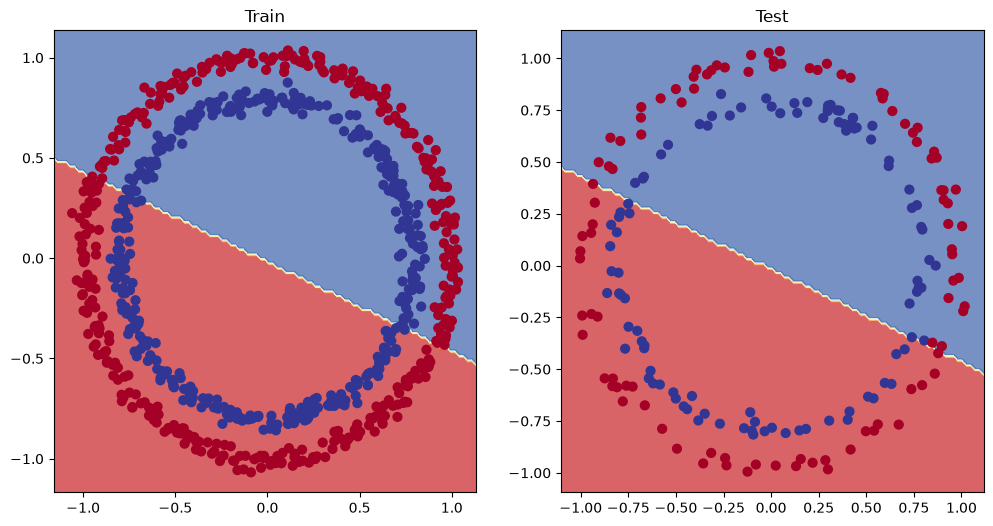

In [27]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [28]:
weight = 0.7
bias = 0.3

X_regression = torch.arange(start=0, end=1, step=0.01).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [29]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

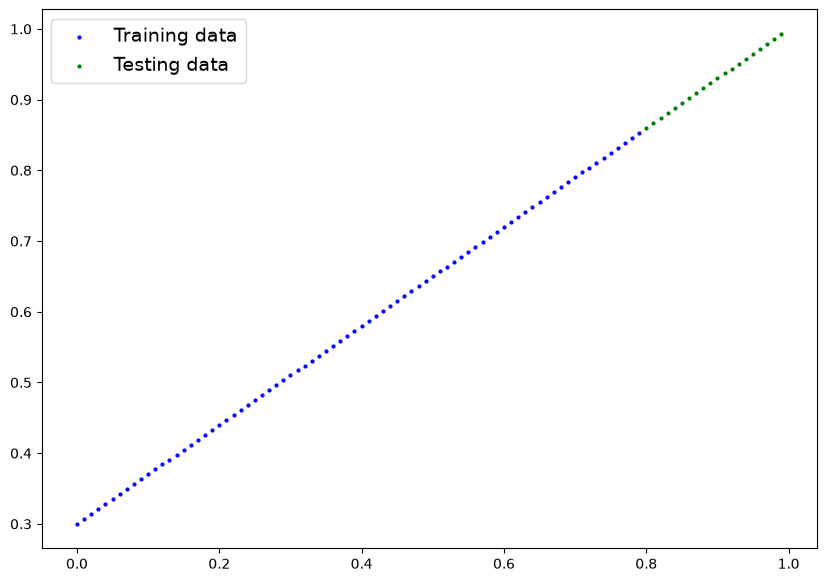

In [30]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)

In [31]:
model_2 = nn.Sequential(
  nn.Linear(in_features=1, out_features=10),
  nn.Linear(in_features=10, out_features=10),
  nn.Linear(in_features=10, out_features=1)
)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [32]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [33]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
  model_2.train()

  y_pred = model_2(X_train_regression)

  loss = loss_fn(y_pred, y_train_regression)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_2.eval()

  with torch.inference_mode():
    test_pred = model_2(X_test_regression)

    test_loss = loss_fn(test_pred, X_test_regression)
  
  if epoch % 100 == 0:
    print(f"Epoch : {epoch} | Loss : {loss:.5f} | Test Loss : {test_loss:.5f} ") 

Epoch : 0 | Loss : 0.75986 | Test Loss : 0.50993 
Epoch : 100 | Loss : 0.09309 | Test Loss : 0.02338 
Epoch : 200 | Loss : 0.07376 | Test Loss : 0.02335 
Epoch : 300 | Loss : 0.06745 | Test Loss : 0.03362 
Epoch : 400 | Loss : 0.06107 | Test Loss : 0.02348 
Epoch : 500 | Loss : 0.05698 | Test Loss : 0.02678 
Epoch : 600 | Loss : 0.04857 | Test Loss : 0.04476 
Epoch : 700 | Loss : 0.06109 | Test Loss : 0.02385 
Epoch : 800 | Loss : 0.05600 | Test Loss : 0.04575 
Epoch : 900 | Loss : 0.05571 | Test Loss : 0.03365 


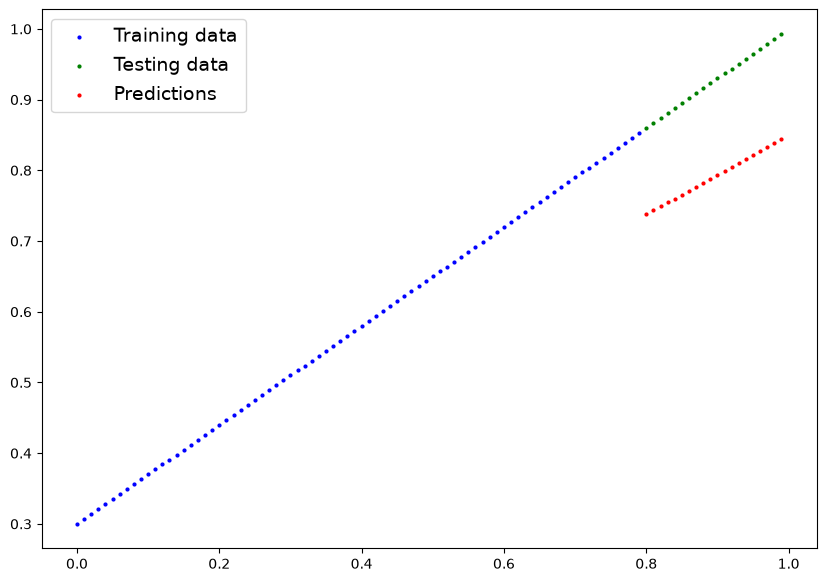

In [34]:
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

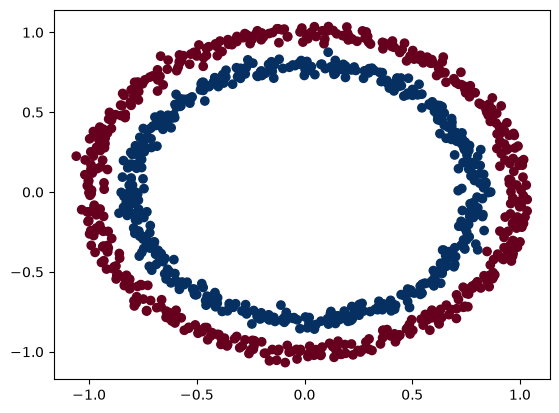

In [35]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X_new, y_new = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [36]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X_new).type(torch.float)
y = torch.from_numpy(y_new).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size=0.2,
                                                    random_state=42)

# len(X_train), len(y_train), len(X_test), len(y_test),
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [37]:
# Build model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [38]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

In [39]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
  model_3.train()

  y_logits = model_3(X_train.to(device)).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train.to(device))
  acc = accuracy_fn(y_true=y_train.to(device), y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_3.eval()

  with torch.inference_mode():
    test_logits = model_3(X_test.to(device)).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test.to(device))
    test_acc = accuracy_fn(y_true=y_test.to(device), y_pred=test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss : {loss:.5f} | Acc : {acc:.5f}% | Test Loss : {test_loss:.5f} | Test Acc : {test_acc:.5f}%")

Epoch: 0 | Loss : 0.69286 | Acc : 52.00000% | Test Loss : 0.69301 | Test Acc : 49.50000%
Epoch: 100 | Loss : 0.68939 | Acc : 52.00000% | Test Loss : 0.69221 | Test Acc : 49.50000%
Epoch: 200 | Loss : 0.68507 | Acc : 62.50000% | Test Loss : 0.69050 | Test Acc : 57.12500%
Epoch: 300 | Loss : 0.67706 | Acc : 57.00000% | Test Loss : 0.68823 | Test Acc : 51.87500%
Epoch: 400 | Loss : 0.66673 | Acc : 57.00000% | Test Loss : 0.68667 | Test Acc : 52.62500%
Epoch: 500 | Loss : 0.65592 | Acc : 56.50000% | Test Loss : 0.68476 | Test Acc : 53.75000%
Epoch: 600 | Loss : 0.64381 | Acc : 60.50000% | Test Loss : 0.67741 | Test Acc : 54.12500%
Epoch: 700 | Loss : 0.62615 | Acc : 67.50000% | Test Loss : 0.66266 | Test Acc : 61.37500%
Epoch: 800 | Loss : 0.60052 | Acc : 73.00000% | Test Loss : 0.64008 | Test Acc : 67.12500%
Epoch: 900 | Loss : 0.55893 | Acc : 82.50000% | Test Loss : 0.60333 | Test Acc : 77.50000%


In [45]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test.to(device)))).squeeze()

y_preds[:10], y[:10]

(tensor([1., 0., 1., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

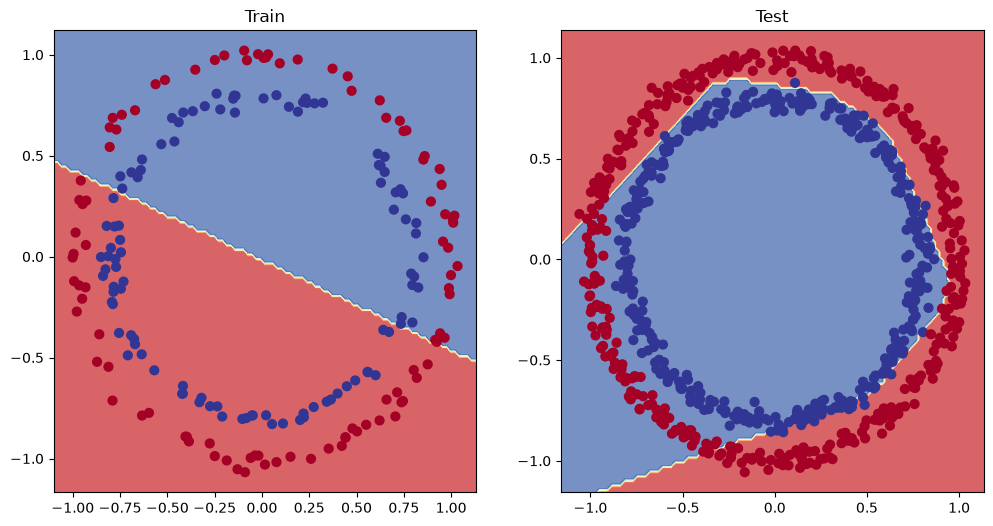

In [46]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

In [47]:
A = torch.arange(-10, 10, 1, dtype=torch.float)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

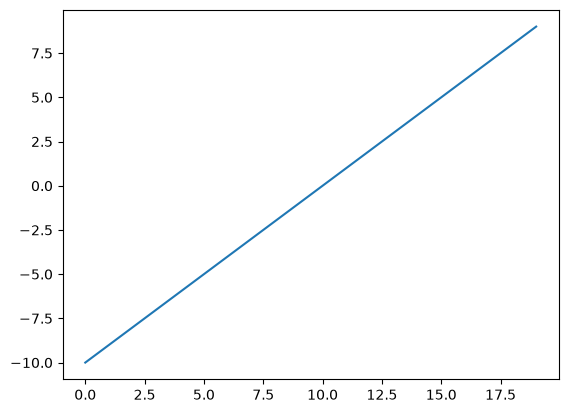

In [48]:
plt.plot(A)

In [49]:
def relu(x):
  return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

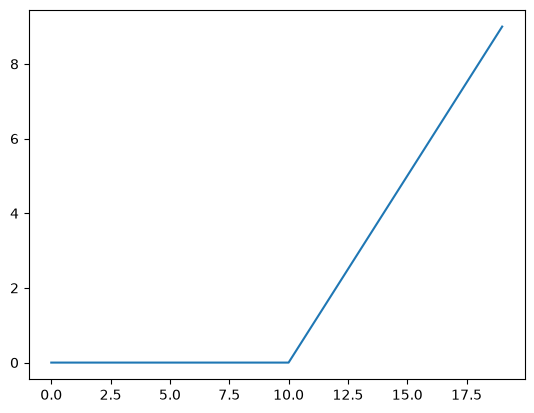

In [51]:
plt.plot(relu(A))

In [52]:
# Create a custom sigmoid function
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

# Test custom sigmoid on toy tensor
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

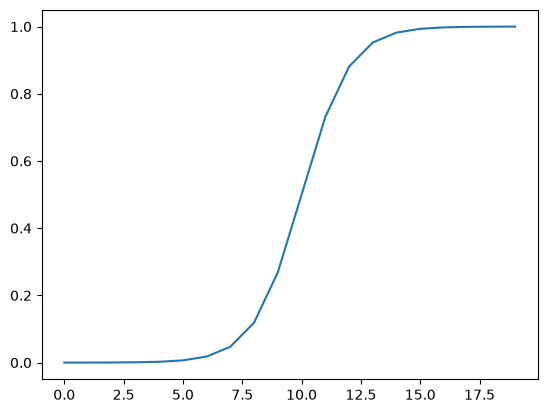

In [54]:
# Plot sigmoid activated toy tensor
plt.plot(sigmoid(A));

Multiclass